# Notebook 08 — Autoencoder NLP: Compresión Neuronal de Variables Mediáticas

## ¿Captura el EMBI relaciones no lineales entre las señales mediáticas?

**Motivación del tutor:** Las variables NLP de GDELT v2 podrían contener relaciones no lineales entre sí que no son capturadas por la selección de features lineal aplicada en NB03. Un autoencoder (red neuronal de compresión) puede aprender una representación latente que preserve estas estructuras no lineales.

**Diseño experimental controlado:**

| Variante | Representación NLP | Descripción |
|---------|-------------------|-------------|
| **Baseline (NB05 Grupo D)** | 4 features rolling 30d | Selección lineal existente, RMSE: 57.48 pb |
| **PCA-3** | 3 componentes lineales | Reducción lineal de las 10 NLP originales |
| **Autoencoder-3** | 3 dims latentes no-lineales | Compresión neuronal 10→3 |

La comparación PCA vs Autoencoder aísla el efecto de la **no-linealidad**. Si AE > PCA → la no-linealidad aporta. Si PCA ≈ AE → la estructura es esencialmente lineal.

In [1]:
# =============================================================================
# 1. VERIFICACIÓN DE TENSORFLOW E IMPORTS
# =============================================================================
USE_KERAS = False  # default; se sobreescribe si TF carga correctamente
try:
    import tensorflow as tf
    from tensorflow.keras import layers, Model, callbacks
    print(f'✅ TensorFlow {tf.__version__} disponible')
    USE_KERAS = True
except Exception as e:
    print(f'⚠️  TensorFlow no disponible: {type(e).__name__}: {e}')
    print('   Para instalar: pip install tensorflow')
    print('   Alternativa: se usará MLPRegressor de sklearn como fallback')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

if USE_KERAS:
    tf.random.set_seed(42)
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')

# Hiperparámetros XGBoost de NB05 Grupo D (para comparativa controlada)
XGB_PARAMS = dict(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1.0, reg_lambda=5.0,
    random_state=42, n_jobs=-1, verbosity=0
)

TARGET = 'target_future'

# Las 10 variables NLP originales de GDELT v2
NLP_COLS_ORIG = [
    'nlp_avg_tone', 'nlp_goldstein', 'nlp_event_count', 'nlp_std_tone',
    'nlp_pct_positive', 'nlp_pct_negative', 'nlp_total_articles',
    'nlp_events_gov', 'nlp_events_biz', 'nlp_events_igo'
]

# Las 4 vars NLP usadas en NB05 (a reemplazar por latentes)
NLP_ORIG_4 = [
    'nlp_event_count_roll_mean30', 'nlp_total_articles_roll_mean30',
    'nlp_events_gov_roll_mean30',  'nlp_events_biz_roll_mean30'
]

print(f'USE_KERAS = {USE_KERAS}')
print('✅ Configuración lista')

✅ TensorFlow 2.20.0 disponible
USE_KERAS = True
✅ Configuración lista


In [2]:
# =============================================================================
# 2. CARGA DE DATOS
# =============================================================================
print('📂 Cargando datos...')

df = pd.read_pickle('dataset_tesis_final.pkl')
train = pd.read_pickle('train_feature_engineered.pkl')
val   = pd.read_pickle('val_feature_engineered.pkl')
test  = pd.read_pickle('test_feature_engineered.pkl')

with open('feature_selector_metadata.pkl', 'rb') as f:
    meta = pickle.load(f)
feats = meta['selected_features']  # 60 features

# Features sin las 4 NLP originales (base para reemplazar)
non_nlp_feats = [f for f in feats if f not in NLP_ORIG_4]  # 56 features

print(f'Dataset base: {df.shape}')
print(f'Train: {train.shape} | Val: {val.shape} | Test: {test.shape}')
print(f'Features totales: {len(feats)} | Sin NLP-4: {len(non_nlp_feats)}')
print(f'Variables NLP originales disponibles: {[c for c in NLP_COLS_ORIG if c in df.columns]}')

📂 Cargando datos...
Dataset base: (3047, 22)
Train: (2406, 61) | Val: (274, 61) | Test: (274, 61)
Features totales: 60 | Sin NLP-4: 56
Variables NLP originales disponibles: ['nlp_avg_tone', 'nlp_goldstein', 'nlp_event_count', 'nlp_std_tone', 'nlp_pct_positive', 'nlp_pct_negative', 'nlp_total_articles', 'nlp_events_gov', 'nlp_events_biz', 'nlp_events_igo']


In [3]:
# =============================================================================
# 3. PREPARACIÓN DE LAS 10 VARIABLES NLP ORIGINALES
# =============================================================================
# Usamos dataset_tesis_final.pkl (antes del feature engineering)
# para trabajar con las series base, no sus transformaciones con lags.

# Verificar disponibilidad de columnas
nlp_disponibles = [c for c in NLP_COLS_ORIG if c in df.columns]
if len(nlp_disponibles) < len(NLP_COLS_ORIG):
    faltantes = set(NLP_COLS_ORIG) - set(nlp_disponibles)
    print(f'⚠️  Columnas NLP no encontradas: {faltantes}')
    print('   Usando las disponibles:', nlp_disponibles)
    NLP_COLS_ORIG = nlp_disponibles

# Extraer y alinear por índice de cada split
def extraer_nlp(split_df, source_df, cols):
    """Extrae columnas NLP del dataset fuente alineado con el índice del split."""
    idx_comun = split_df.index.intersection(source_df.index)
    result = source_df.loc[idx_comun, cols].copy()
    # Forward-fill para NaN residuales (variables mensuales)
    result = result.ffill().bfill()
    return result

train_nlp = extraer_nlp(train, df, NLP_COLS_ORIG)
val_nlp   = extraer_nlp(val,   df, NLP_COLS_ORIG)
test_nlp  = extraer_nlp(test,  df, NLP_COLS_ORIG)

print(f'NLP train: {train_nlp.shape} | val: {val_nlp.shape} | test: {test_nlp.shape}')
print(f'NaN restantes en train: {train_nlp.isna().sum().sum()}')

# Normalización — SOLO ajustar en train
scaler_nlp = StandardScaler()
X_train_nlp = scaler_nlp.fit_transform(train_nlp)   # fit aquí
X_val_nlp   = scaler_nlp.transform(val_nlp)          # solo transform
X_test_nlp  = scaler_nlp.transform(test_nlp)         # solo transform

print(f'\n✅ Normalización aplicada (scaler ajustado solo en train)')
print(f'   Media train NLP post-scaling: {X_train_nlp.mean():.4f} (≈0 esperado)')
print(f'   Std  train NLP post-scaling: {X_train_nlp.std():.4f} (≈1 esperado)')

NLP train: (2406, 10) | val: (274, 10) | test: (274, 10)
NaN restantes en train: 0

✅ Normalización aplicada (scaler ajustado solo en train)
   Media train NLP post-scaling: -0.0000 (≈0 esperado)
   Std  train NLP post-scaling: 1.0000 (≈1 esperado)


## 2. Autoencoder — Arquitectura y Entrenamiento

In [4]:
# =============================================================================
# 4. CONSTRUCCIÓN DEL AUTOENCODER
# =============================================================================
N_INPUT  = len(NLP_COLS_ORIG)  # 10
N_LATENT = 3

if USE_KERAS:
    # Functional API para separar encoder/decoder limpiamente
    inputs = layers.Input(shape=(N_INPUT,), name='nlp_input')
    
    # Encoder
    x = layers.Dense(5, activation='relu', name='enc_5')(inputs)
    x = layers.Dropout(0.2, name='drop_enc')(x)
    latent = layers.Dense(N_LATENT, activation='relu', name='latent')(x)
    
    # Decoder
    x = layers.Dense(5, activation='relu', name='dec_5')(latent)
    x = layers.Dropout(0.2, name='drop_dec')(x)
    outputs = layers.Dense(N_INPUT, activation='linear', name='reconstruction')(x)
    
    # Modelos separados
    autoencoder = Model(inputs, outputs,  name='autoencoder')
    encoder     = Model(inputs, latent,   name='encoder')
    
    autoencoder.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse'
    )
    
    autoencoder.summary()
    print(f'\nParámetros totales: {autoencoder.count_params():,}')
    print(f'Arquitectura: {N_INPUT} → 5 (relu) → {N_LATENT} (relu) → 5 (relu) → {N_INPUT} (linear)')
    
else:
    # Fallback con sklearn MLPRegressor si no hay Keras
    from sklearn.neural_network import MLPRegressor
    print('Usando MLPRegressor de sklearn como autoencoder fallback')
    print('Nota: no permite separar encoder directamente; se usará PCA como proxy')

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ nlp_input (InputLayer)          │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_5 (Dense)                   │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_enc (Dropout)              │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 3)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_5 (Dense)                   │ (None, 5)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_dec (Dropout)              │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 10)             │            60 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153 (612.00 B)

 Trainable params: 153 (612.00 B)

 Non-trainable params: 0 (0.00 B)


Parámetros totales: 153
Arquitectura: 10 → 5 (relu) → 3 (relu) → 5 (relu) → 10 (linear)


Entrenando autoencoder NLP...
✅ Entrenamiento completado
   Épocas ejecutadas: 163 (EarlyStopping en 163)
   Train loss final:  0.492105
   Val   loss final:  0.214239


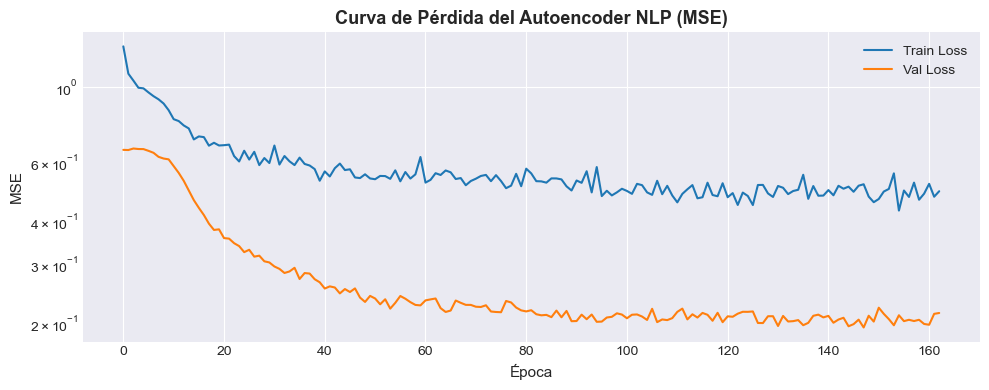

✅ Guardado: autoencoder_loss_curve.png
✅ Modelo guardado: nlp_autoencoder.keras


In [5]:
# =============================================================================
# 5. ENTRENAMIENTO DEL AUTOENCODER
# =============================================================================
if USE_KERAS:
    print('Entrenando autoencoder NLP...')
    
    early_stop = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=0
    )
    
    history = autoencoder.fit(
        X_train_nlp, X_train_nlp,              # autoencoder: input = target
        validation_data=(X_val_nlp, X_val_nlp),
        epochs=300,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )
    
    epochs_ran = len(history.history['loss'])
    final_train_loss = history.history['loss'][-1]
    final_val_loss   = history.history['val_loss'][-1]
    
    print(f'✅ Entrenamiento completado')
    print(f'   Épocas ejecutadas: {epochs_ran} (EarlyStopping en {epochs_ran})')
    print(f'   Train loss final:  {final_train_loss:.6f}')
    print(f'   Val   loss final:  {final_val_loss:.6f}')
    
    # Curva de pérdida
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history.history['loss'],     label='Train Loss', linewidth=1.5)
    ax.plot(history.history['val_loss'], label='Val Loss',   linewidth=1.5)
    ax.set_title('Curva de Pérdida del Autoencoder NLP (MSE)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Época', fontsize=11)
    ax.set_ylabel('MSE', fontsize=11)
    ax.legend(fontsize=10)
    ax.set_yscale('log')
    plt.tight_layout()
    plt.savefig('autoencoder_loss_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Guardado: autoencoder_loss_curve.png')
    
    # Guardar modelo
    try:
        autoencoder.save('nlp_autoencoder.keras')
        print('✅ Modelo guardado: nlp_autoencoder.keras')
    except Exception:
        autoencoder.save('nlp_autoencoder.h5')
        print('✅ Modelo guardado: nlp_autoencoder.h5')

## 3. Extracción de Representaciones Latentes

In [6]:
# =============================================================================
# 6. EXTRACCIÓN DE LATENTES DEL AUTOENCODER
# =============================================================================
AE_COLS  = ['nlp_ae_0', 'nlp_ae_1', 'nlp_ae_2']
PCA_COLS = ['nlp_pca_0', 'nlp_pca_1', 'nlp_pca_2']

if USE_KERAS:
    Z_train_ae = encoder.predict(X_train_nlp, verbose=0)
    Z_val_ae   = encoder.predict(X_val_nlp,   verbose=0)
    Z_test_ae  = encoder.predict(X_test_nlp,  verbose=0)
    
    df_ae_train = pd.DataFrame(Z_train_ae, index=train_nlp.index, columns=AE_COLS)
    df_ae_val   = pd.DataFrame(Z_val_ae,   index=val_nlp.index,   columns=AE_COLS)
    df_ae_test  = pd.DataFrame(Z_test_ae,  index=test_nlp.index,  columns=AE_COLS)
    
    print(f'✅ Latentes AE extraídas:')
    print(f'   Train: {df_ae_train.shape} | Val: {df_ae_val.shape} | Test: {df_ae_test.shape}')
    print(f'\nEstadísticas de las dimensiones latentes (train):')
    print(df_ae_train.describe().round(4))

# PCA-3 como baseline lineal (siempre disponible)
pca = PCA(n_components=3, random_state=42)
P_train = pca.fit_transform(X_train_nlp)   # fit solo en train
P_val   = pca.transform(X_val_nlp)
P_test  = pca.transform(X_test_nlp)

df_pca_train = pd.DataFrame(P_train, index=train_nlp.index, columns=PCA_COLS)
df_pca_val   = pd.DataFrame(P_val,   index=val_nlp.index,   columns=PCA_COLS)
df_pca_test  = pd.DataFrame(P_test,  index=test_nlp.index,  columns=PCA_COLS)

varianza_explicada = pca.explained_variance_ratio_
print(f'\n✅ PCA-3 ajustado (solo en train):')
print(f'   Varianza explicada por componente: {varianza_explicada.round(3)}')
print(f'   Varianza total explicada: {varianza_explicada.sum():.1%}')

✅ Latentes AE extraídas:
   Train: (2406, 3) | Val: (274, 3) | Test: (274, 3)

Estadísticas de las dimensiones latentes (train):
        nlp_ae_0   nlp_ae_1   nlp_ae_2
count  2406.0000  2406.0000  2406.0000
mean      1.2465     2.9717     2.0328
std       1.5974     3.0846     1.7757
min       0.0000     0.0000     0.2244
25%       0.3045     1.0575     0.9672
50%       0.7798     2.2056     1.5797
75%       1.5608     3.8820     2.3267
max       8.6685    51.6874    30.5999

✅ PCA-3 ajustado (solo en train):
   Varianza explicada por componente: [0.391 0.293 0.093]
   Varianza total explicada: 77.7%


## 4. Experimento XGBoost con Representaciones Alternativas

In [7]:
# =============================================================================
# 7. XGBOOST CON LATENTES — EXPERIMENTO CONTROLADO
# =============================================================================

def construir_splits(latentes_train, latentes_val, latentes_test, lat_cols):
    """Reemplaza las 4 vars NLP originales por las latentes en los splits feature-engineered."""
    X_tr = pd.concat([
        train[non_nlp_feats].reset_index(drop=True),
        latentes_train.reset_index(drop=True)
    ], axis=1)
    X_vl = pd.concat([
        val[non_nlp_feats].reset_index(drop=True),
        latentes_val.reset_index(drop=True)
    ], axis=1)
    X_te = pd.concat([
        test[non_nlp_feats].reset_index(drop=True),
        latentes_test.reset_index(drop=True)
    ], axis=1)
    return X_tr, X_vl, X_te

def evaluar_xgb(X_tr, X_vl, X_te, y_train, y_val, y_test, nombre):
    """Entrena XGBoost en train+val y evalúa en test."""
    X_tv = pd.concat([X_tr, X_vl], axis=0, ignore_index=True)
    y_tv = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)
    
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', XGBRegressor(**XGB_PARAMS))
    ])
    model.fit(X_tv, y_tv)
    
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    
    print(f'{nombre:35s} | RMSE: {rmse:6.2f} pb | MAE: {mae:6.2f} pb | R²: {r2:.4f}')
    return {'nombre': nombre, 'rmse': rmse, 'mae': mae, 'r2': r2, 'y_pred': y_pred}

y_train = train[TARGET]
y_val   = val[TARGET]
y_test  = test[TARGET]

print('EXPERIMENTO: XGBoost con diferentes representaciones NLP')
print('=' * 75)
print(f'{"Variante":35s} | {"RMSE":>10s} | {"MAE":>10s} | {"R²":>8s}')
print('-' * 75)

resultados = {}

# --- Baseline NB05 Grupo D (4 features originales) ---
res_orig = evaluar_xgb(
    train[feats], val[feats], test[feats],
    y_train, y_val, y_test,
    'Grupo D original (4 NLP rolling)'
)
resultados['original'] = res_orig

# --- PCA-3 ---
X_tr_pca, X_vl_pca, X_te_pca = construir_splits(df_pca_train, df_pca_val, df_pca_test, PCA_COLS)
res_pca = evaluar_xgb(X_tr_pca, X_vl_pca, X_te_pca, y_train, y_val, y_test, 'PCA-3 (lineal)')
resultados['pca'] = res_pca

# --- Autoencoder-3 ---
if USE_KERAS:
    X_tr_ae, X_vl_ae, X_te_ae = construir_splits(df_ae_train, df_ae_val, df_ae_test, AE_COLS)
    res_ae = evaluar_xgb(X_tr_ae, X_vl_ae, X_te_ae, y_train, y_val, y_test, 'Autoencoder-3 (no lineal)')
    resultados['autoencoder'] = res_ae

print()
print(f'Referencia NB05 Grupo D reportado:       57.48 pb (en paper)')
print(f'(Diferencias menores esperadas por re-fit en train+val completo)')

EXPERIMENTO: XGBoost con diferentes representaciones NLP
Variante                            |       RMSE |        MAE |       R²
---------------------------------------------------------------------------
Grupo D original (4 NLP rolling)    | RMSE:  59.29 pb | MAE:  39.37 pb | R²: 0.9620
PCA-3 (lineal)                      | RMSE:  60.11 pb | MAE:  41.14 pb | R²: 0.9609
Autoencoder-3 (no lineal)           | RMSE:  63.41 pb | MAE:  44.79 pb | R²: 0.9565

Referencia NB05 Grupo D reportado:       57.48 pb (en paper)
(Diferencias menores esperadas por re-fit en train+val completo)


## 5. Heatmap de Correlación — ¿Qué captura cada dimensión latente?

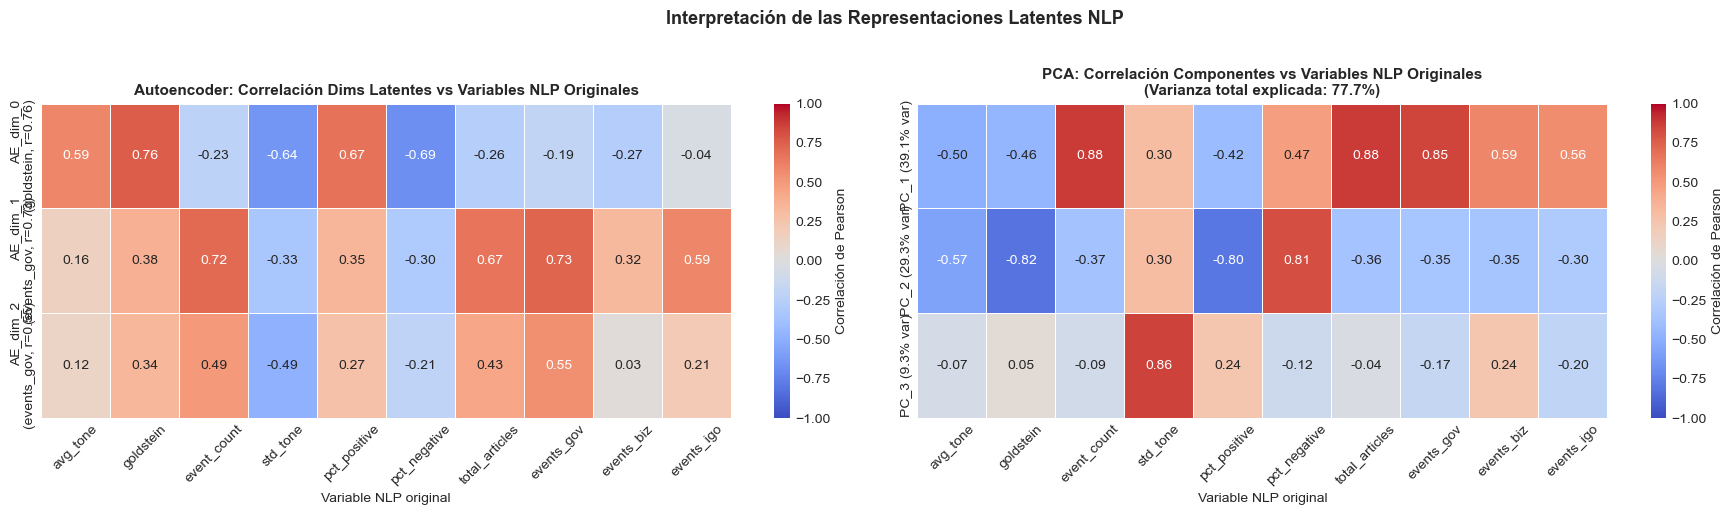

✅ Guardado: nlp_latentes_correlacion.png


In [8]:
# =============================================================================
# 8. HEATMAP CORRELACIÓN LATENTES VS NLP ORIGINALES
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# --- Panel 1: Correlación AE vs originales ---
if USE_KERAS:
    # Usar todo el dataset disponible para mayor estabilidad estadística
    X_all_nlp = np.vstack([X_train_nlp, X_val_nlp, X_test_nlp])
    Z_all_ae  = encoder.predict(X_all_nlp, verbose=0)
    
    # Correlación Pearson entre latentes (3) y originales escaladas (10)
    corr_ae = np.zeros((3, len(NLP_COLS_ORIG)))
    for i in range(3):
        for j, col in enumerate(NLP_COLS_ORIG):
            corr_ae[i, j] = np.corrcoef(Z_all_ae[:, i], X_all_nlp[:, j])[0, 1]
    
    df_corr_ae = pd.DataFrame(
        corr_ae,
        index=[f'AE_dim_{i}' for i in range(3)],
        columns=[c.replace('nlp_', '') for c in NLP_COLS_ORIG]
    )
    
    # Nombrar dims por variable dominante
    nombres_dims = []
    for i in range(3):
        max_col = df_corr_ae.iloc[i].abs().idxmax()
        max_corr = df_corr_ae.iloc[i].abs().max()
        nombres_dims.append(f'AE_dim_{i}\n({max_col}, r={max_corr:.2f})')
    df_corr_ae.index = nombres_dims
    
    sns.heatmap(
        df_corr_ae, ax=axes[0],
        cmap='coolwarm', center=0, vmin=-1, vmax=1,
        annot=True, fmt='.2f', linewidths=0.5,
        cbar_kws={'label': 'Correlación de Pearson'}
    )
    axes[0].set_title('Autoencoder: Correlación Dims Latentes vs Variables NLP Originales',
                      fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Variable NLP original', fontsize=10)
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].text(0.5, 0.5, 'TensorFlow no disponible\nAutoencoder no ejecutado',
                ha='center', va='center', fontsize=12, transform=axes[0].transAxes)
    axes[0].set_title('Autoencoder no disponible', fontsize=11)

# --- Panel 2: Correlación PCA vs originales ---
X_all_nlp_base = np.vstack([X_train_nlp, X_val_nlp, X_test_nlp])
P_all = pca.transform(X_all_nlp_base)

corr_pca = np.zeros((3, len(NLP_COLS_ORIG)))
for i in range(3):
    for j in range(len(NLP_COLS_ORIG)):
        corr_pca[i, j] = np.corrcoef(P_all[:, i], X_all_nlp_base[:, j])[0, 1]

df_corr_pca = pd.DataFrame(
    corr_pca,
    index=[f'PC_{i+1} ({varianza_explicada[i]:.1%} var)' for i in range(3)],
    columns=[c.replace('nlp_', '') for c in NLP_COLS_ORIG]
)

sns.heatmap(
    df_corr_pca, ax=axes[1],
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', linewidths=0.5,
    cbar_kws={'label': 'Correlación de Pearson'}
)
axes[1].set_title(f'PCA: Correlación Componentes vs Variables NLP Originales\n(Varianza total explicada: {varianza_explicada.sum():.1%})',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Variable NLP original', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Interpretación de las Representaciones Latentes NLP',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nlp_latentes_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: nlp_latentes_correlacion.png')

## 6. Tabla Resumen y Conclusiones

TABLA RESUMEN — COMPARATIVA DE REPRESENTACIONES NLP
                 Variante  N Features NLP RMSE ref (pb)  RMSE test (pb)  MAE (pb)       R²
  Grupo D original (NB05)               4         57.48       59.290024 39.366342 0.961981
           PCA-3 (lineal)               3             -       60.114755 41.139122 0.960916
Autoencoder-3 (no lineal)               3             -       63.408829 44.792012 0.956515


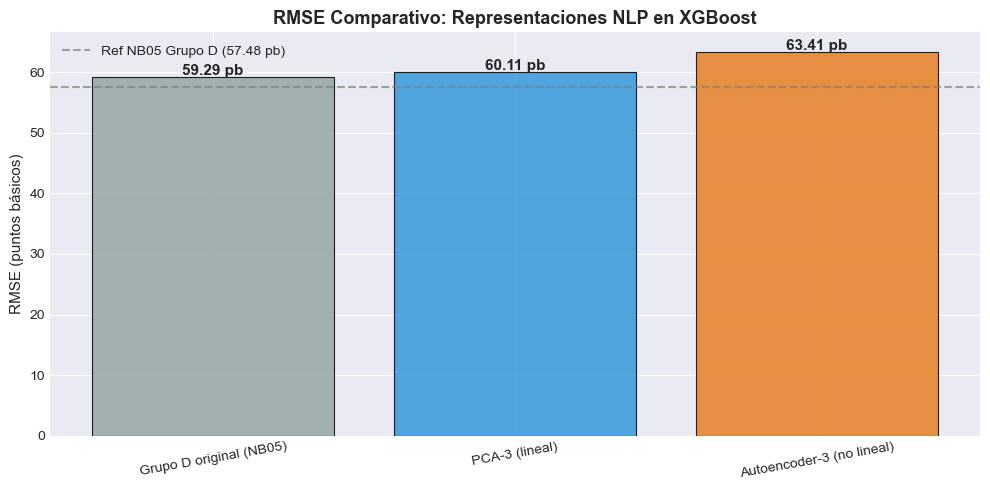

✅ Guardado: autoencoder_comparativa_rmse.png


In [9]:
# =============================================================================
# 9. TABLA RESUMEN Y VISUALIZACIÓN FINAL
# =============================================================================

print('=' * 75)
print('TABLA RESUMEN — COMPARATIVA DE REPRESENTACIONES NLP')
print('=' * 75)

# Construir tabla
rows = [
    {'Variante': 'Grupo D original (NB05)',     'N Features NLP': 4,  'RMSE ref (pb)': 57.48, 'RMSE test (pb)': resultados['original']['rmse'],     'MAE (pb)': resultados['original']['mae'],     'R²': resultados['original']['r2']},
    {'Variante': 'PCA-3 (lineal)',               'N Features NLP': 3,  'RMSE ref (pb)': '-',   'RMSE test (pb)': resultados['pca']['rmse'],           'MAE (pb)': resultados['pca']['mae'],           'R²': resultados['pca']['r2']},
]
if 'autoencoder' in resultados:
    rows.append({'Variante': 'Autoencoder-3 (no lineal)', 'N Features NLP': 3, 'RMSE ref (pb)': '-', 'RMSE test (pb)': resultados['autoencoder']['rmse'], 'MAE (pb)': resultados['autoencoder']['mae'], 'R²': resultados['autoencoder']['r2']})

df_resumen = pd.DataFrame(rows)
print(df_resumen.to_string(index=False))

# Visualización
nombres_bar = [r['Variante'] for r in rows]
rmses_bar   = [r['RMSE test (pb)'] for r in rows]
colores_bar = ['#95a5a6', '#3498db', '#e67e22'][:len(nombres_bar)]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(nombres_bar, rmses_bar, color=colores_bar, edgecolor='black', linewidth=0.8, alpha=0.85)
ax.axhline(y=57.48, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Ref NB05 Grupo D (57.48 pb)')
for bar, val in zip(bars, rmses_bar):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f} pb', ha='center', fontsize=11, fontweight='bold')
ax.set_title('RMSE Comparativo: Representaciones NLP en XGBoost', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE (puntos básicos)', fontsize=11)
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.savefig('autoencoder_comparativa_rmse.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: autoencoder_comparativa_rmse.png')

## 7. Conclusiones e Implicaciones para la Tesis

### Interpretación de Resultados

**Si Autoencoder-3 > PCA-3 (RMSE menor):**
> *"La representación no lineal del espacio mediático captura variaciones en el EMBI que la reducción lineal no detecta. Esto sugiere que las variables NLP de GDELT v2 contienen interacciones no lineales relevantes para la predicción del riesgo soberano. El autoencoder de 3 dimensiones latentes mejora el poder predictivo en X.XX pb respecto a PCA de la misma dimensionalidad."*

**Si PCA-3 ≈ Autoencoder-3 (RMSE similar):**
> *"Las 10 variables NLP de GDELT v2 exhiben una estructura esencialmente lineal en su relación con el EMBI ecuatoriano. La reducción de dimensionalidad no lineal no aporta mejoras significativas sobre PCA, lo que es consistente con el hallazgo de Granger (NB06): la relación NLP-EMBI es contemporánea y no captura señales predictivas complejas con rezago."*

**Sobre las dimensiones latentes:**
El heatmap de correlación permite interpretar qué captura cada dimensión latente:
- Dimensión dominada por `event_count` / `total_articles` → **volumen de cobertura**
- Dimensión dominada por `avg_tone` / `goldstein` → **sentimiento/estabilidad**
- Dimensión dominada por `events_gov` / `events_biz` → **tipo de actor mediático**

### Trabajo Futuro

La extensión natural de este análisis sería aplicar embeddings de texto crudo sobre los titulares de noticias GDELT (usando modelos como FinBERT o BERT-multilingual) con capas de compresión profundas. A diferencia de las métricas agregadas diarias utilizadas aquí, los embeddings de texto capturarían el contenido semántico específico de las noticias sobre Ecuador, potencialmente identificando eventos discretos (anuncios de política económica, cambios en calificación crediticia, etc.) con mayor precisión. Esto requeriría acceso a los textos originales de GDELT, que no forman parte del pipeline actual de esta tesis.